In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.scrapethissite.com/pages/simple/"
response = requests.get(url)

In [2]:
with open ("html.html" , "w",encoding="utf-8") as f:
    f.write(response.text)

In [3]:
with open ("html.html") as f:
    content = f.read()

In [4]:
soup = BeautifulSoup(content, "html.parser")

In [5]:
h3 = soup.find_all("h3")

In [6]:
countries = soup.find_all('div',class_="country")

In [7]:
data = []

In [8]:
for i in countries:
    name = i.find("h3",class_="country-name").text.strip()
    capital = i.find("span",class_="country-capital").text.strip()
    population = i.find("span",class_="country-population").text.strip()
    area = i.find('span', class_='country-area').text.strip()
    data.append([name,capital,population,area])

In [9]:
df = pd.DataFrame(data,columns=["country","capital","population","area"])

In [24]:
df["area"] = pd.to_numeric(df["area"])
df["population"] = pd.to_numeric(df["population"])

In [25]:
df.to_csv('global_demographics.csv', index=False)

In [26]:
df[df["country"] == "India"]

,country,capital,population,area
104,India,New Delhi,1173108018,3287590.0


In [31]:
import matplotlib.pyplot as plt

In [33]:
top10 = df.sort_values(by="population",ascending=False).head(10)

In [34]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

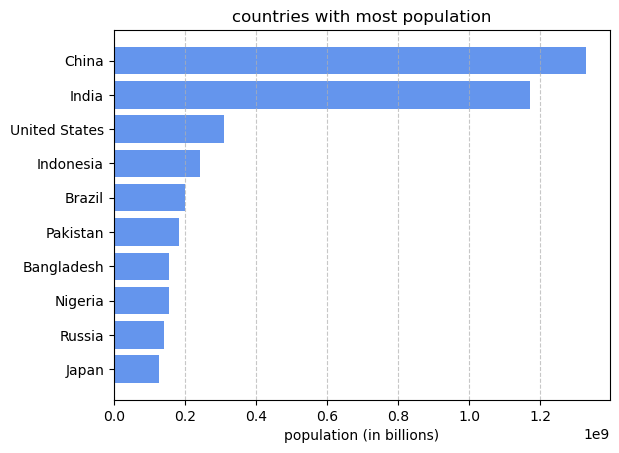

In [40]:
plt.barh(top10["country"],top10["population"],color="cornflowerblue")
plt.title("countries with most population")
plt.xlabel("population (in billions)")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('population_top10.png', bbox_inches='tight', dpi=300)